In [57]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import time
import numpy as np
from matplotlib import image
import matplotlib.pyplot as plt
import scipy.interpolate as sci
import skfmm
from scipy.special import erf
import dedalus.extras.plot_tools as dpt
import dedalus.public as d3
import time

Lx, Lz = 1,1
Nx, Nz = 256,256
Ra_M = -1e10
D_0 = 0
D_H = 1/3
M_0 = 0
M_H = 1
N_s2=4/3
Qrad=0.0028
gamma=100

Prandtl = 1
kappa = (Ra_M * Prandtl/((M_0-M_H)*Lz**3))**(-1/2)
nu = (Ra_M / (Prandtl*(M_0-M_H)*Lz**3))**(-1/2)
print(nu)

# optimal mask parameters (smoothness), given fluid viscosity ν and damping rate γ
ν = nu # viscosity [L**2/T]
γ = 100 # damping rate [1/T]
ϵ = (ν/γ)**(1/2) # damping length scale ϵ = (ν/γ)**(1/2), 
optimal_delta = 3.11346786*ϵ # erf mask smoothness
grid_delta = Lx/Nx
δ = np.max((10*optimal_delta, grid_delta*2))
print(optimal_delta, grid_delta, δ)
print(10*optimal_delta, grid_delta*2, δ)

1e-05
0.0009845649859330252 0.00390625 0.00984564985933025
0.00984564985933025 0.0078125 0.00984564985933025


(256,)
(256, 256)


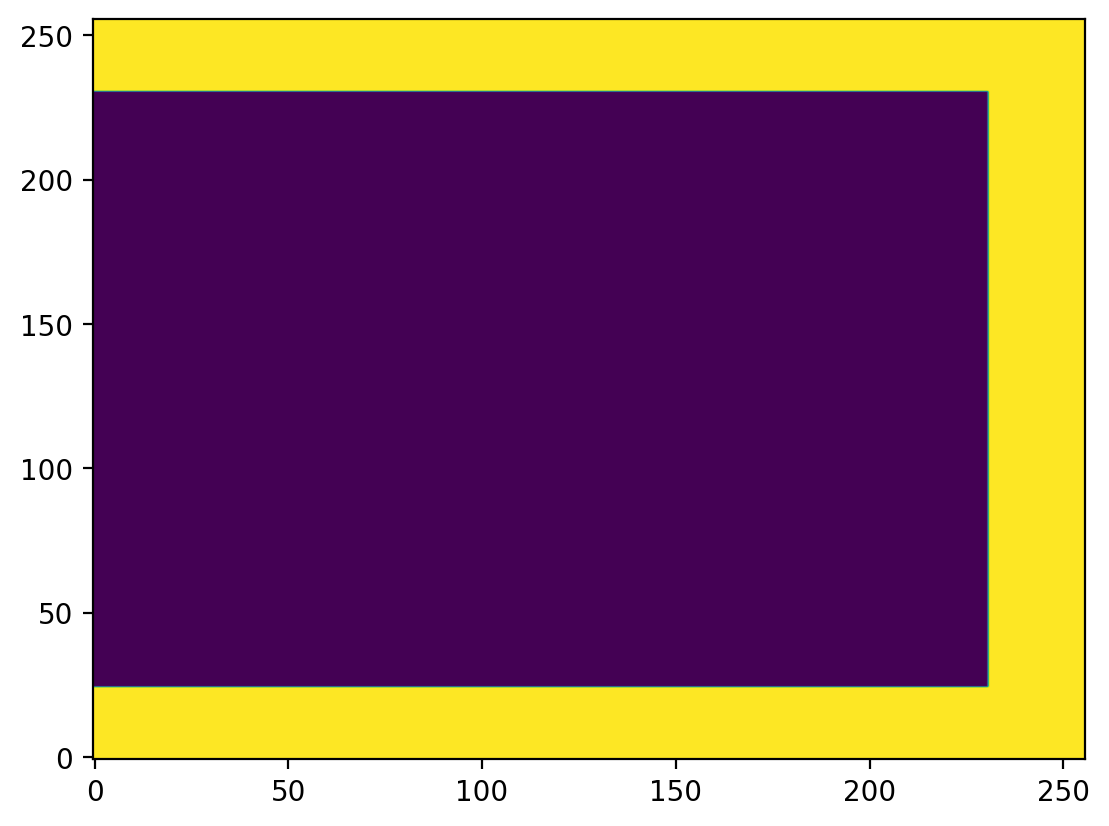

(256,)
Interpolation time: 0.01 seconds
Mask grid shape: (384, 384)


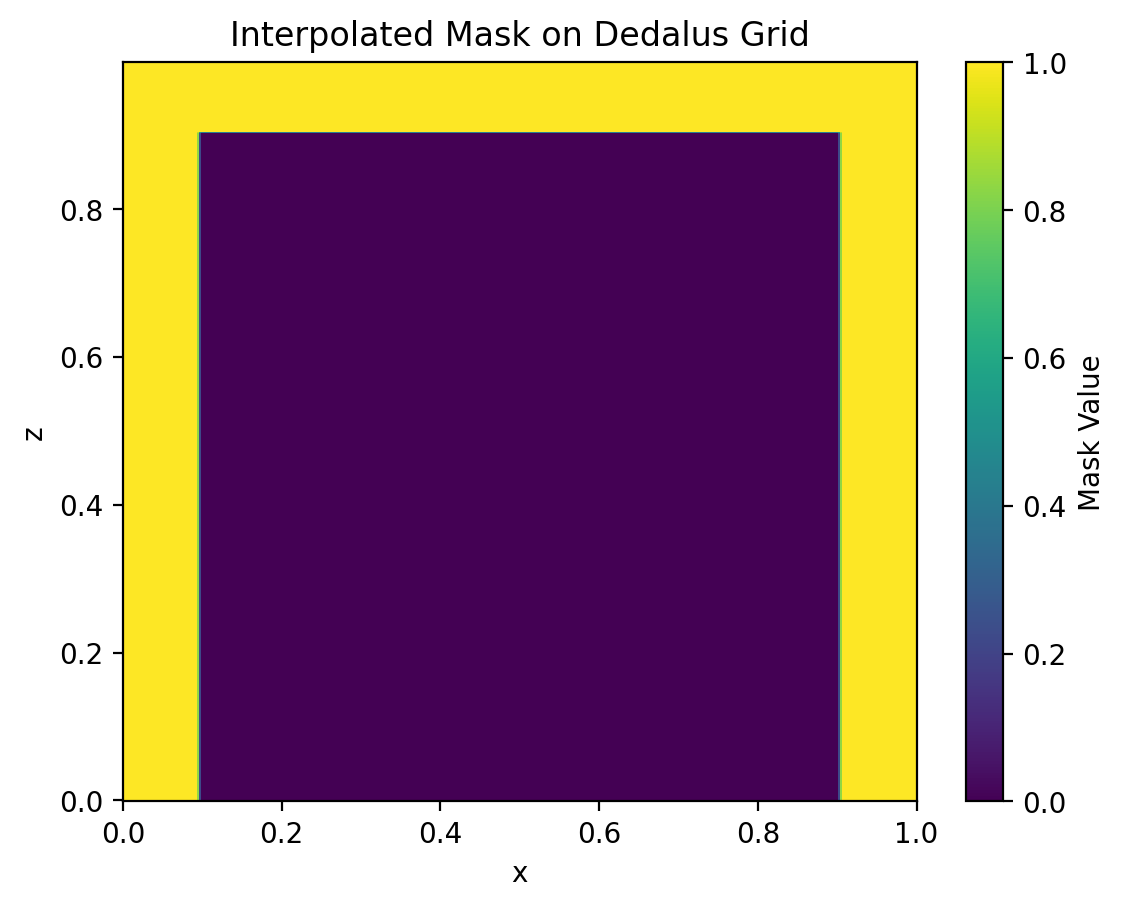

In [58]:
xl = np.linspace(0,Lx,Nx)
zl = np.linspace(0,Lz,Nz)

# def mountain_shape(x):
#     return np.where((x >= 0.4) & (x <= 0.6), 0.02 * np.sin(5*np.pi*(x-0.4)), 0)

# def mountain_shape(x):
#     return -2*(x-0.4)*(x-0.6)



print(xl.shape)
height = mountain_shape(xl)

newcell = np.zeros((Nx,Nz),dtype=int)

#LR Sponge
newcell[:Nx//10][:]=1
newcell[Nx-Nx//10:][:]=1

#Top Sponge
newcell[Nx//10:(Nx-Nx//10),(Nz-Nz//10):]=1



# for i in range(Nx):
#     for j in range(Nz):
#         if height[i] > zl[j]:
#             newcell[j,i] = 0
#         else:
#             newcell[j,i] = 1
print(newcell.shape)

plt.imshow(newcell, origin='lower', aspect='auto')
plt.show()
# newcell = newcell-.5
# plt.imshow(newcell)
# newdistance = skfmm.distance(newcell, dx = 2**(1/2)*Lx/Nx ,periodic=(False,True))
# newdistance = skfmm.distance(newcell, dx = [Lz/Nz,Lx/Nx] ,periodic=(False,True))
# newdistance = newdistance-0.5

def mask(x): return 0.5*(1-erf(np.pi**(1/2)*x))

dtype = np.float64
dealias = 3/2

# Bases
coords = d3.CartesianCoordinates('x', 'z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)
x = dist.local_grid(xbasis)
x= x[:,0]
z = dist.local_grid(zbasis)
z = z[0,:]
print(z.shape)
# z = Lz - z
# x_hi = np.linspace(0, Lx, Nx)
# z_hi = np.linspace(0, Lz, Nz)

# distance_func = sci.RegularGridInterpolator((zl, xl), newdistance, bounds_error=True, fill_value=-0.5)
# # Generate a meshgrid of x and z
# X,Z = np.meshgrid(x, z, indexing='ij')

# # Stack the coordinates for interpolation
# # points = np.stack((Z.ravel(), X.ravel()),axis=-1)  # Shape (Nx*Nz, 2)

# # Interpolate over the grid
# # distance_hi = distance_func(points).reshape(X.shape)
# distance_hi = distance_func((z[:,None],x[None,:]))
# # distance_hi = distance_func((z,x))
# print(newdistance.shape)
# fig = plt.figure(figsize=[12,6])
# ax1 = fig.add_subplot(1,2,1)
# # mesh1 = ax1.contour(np.meshgrid(zl,xl), newdistance, levels=10)
# mesh1 = ax1.pcolormesh(xl,zl, newdistance, shading='nearest', vmin=-0.5, vmax=0.5)
# plt.colorbar(mesh1)
# ax2 = fig.add_subplot(1,2,2)
# mesh2 = ax2.pcolormesh(x,z, distance_hi, shading='nearest', vmin=-0.5, vmax=0.5)
# plt.colorbar(mesh2)

# for ax in [ax1,ax2]:
#     ax.set_aspect(1)
#     # ax.plot(x_circ, y_circ, c='k')
#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 1)
    

# fig, ax = plt.subplots(figsize=[12,12])
# # plot = ax.pcolormesh(x_hi, z_hi, mask(distance_hi/δ),cmap='Greys')
# plot = ax.pcolormesh(x,z, mask(distance_hi/δ),cmap='Greys')
# ax.set(aspect=1)
# plt.colorbar(plot,ax=ax)
# plt.show()



dtype = np.float64
dealias = 3/2

# Bases
coords = d3.CartesianCoordinates('x', 'z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

def mask(x): return 0.5*(1-erf(np.pi**(1/2)*x))




# Create mask field
mask_grid = dist.Field(name='mask', bases=(xbasis, zbasis))

# Interpolate mask onto Dedalus grid
mask_grid.change_scales(dealias)
xg = dist.local_grid(xbasis, scale=dealias)
zg = dist.local_grid(zbasis, scale=dealias)
interp_smooth = sci.RegularGridInterpolator((xl, zl), newcell, 
                                            bounds_error=True, fill_value=1)
start_time = time.time()
# print("111",distance_func((zg[:,None],xg[None,:])).shape)
# Vectorized interpolation
X, Z = np.meshgrid(xg[:, 0], zg[0, :], indexing='ij')
mask_grid['g'] = interp_smooth((zg[:,None],xg[None,:]))
# mask_grid['g'] = interp_smooth((zg, xg))  
# mask_grid['g'] = mask(newdistance/δ)

end_time = time.time()

print(f"Interpolation time: {end_time - start_time:.2f} seconds")
print(f"Mask grid shape: {mask_grid['g'].shape}")


# plt.figure(figsize=(5, 20))
# plt.imshow(mask_grid['g'], origin='lower', aspect='auto')
# plt.contour(np.meshgrid(xg[:,0],zg[0,:]), mask_grid['g'])
xplt,zplt=np.meshgrid(xg[:,0],zg[0,:])
# plt.imshow(mask_grid['g'].T)
plt.pcolormesh(zg,xg, mask_grid['g'], shading='nearest')
plt.colorbar(label='Mask Value')
plt.title('Interpolated Mask on Dedalus Grid')
plt.xlabel('x')
plt.ylabel('z')
plt.show()

# plt.plot(xg[:,0],mask_grid['g'][:,80])
# plt.ylim(0, 1)
# plt.show()


In [59]:
import h5py
    
with h5py.File('masks/mask_sp.h5', 'w') as f:
    f['mask'] = mask_grid['g']
    f['x'] = x
    f['z'] = z


In [54]:
import h5py
    
with h5py.File('masks/mask_sptop.h5', 'w') as f:
    f['mask'] = mask_grid['g']
    f['x'] = x
    f['z'] = z
